# Implementation of MCP Neuron for AND and OR Function.

**3.2 Task - 1: Implementation of MCP Neurons:**
1. Design a MCP Neuron for ”AND” Boolean Functions and ”OR” Boolean Functions with two inputs:

Hint:

• Aggregate all the inputs.

• Handcraft a Threshold values for ”AND” and ”OR” Function.

• Implement a if else statement as stated above.

You may use code base provided below or write your own code from scratch:

In [3]:
def MCP_Neurons_AND(X1, X2, T):
  """
  This functions implements basic AND operations with MCP Neuron for two inputs.
  Arguments:
  Inputs:
  X1 (1 nd array): An array of binary values.
  X2 (1 nd array): An array of binary values.
  Output:
  state_neuron(1D-list): An state of neuron 1 0r 0 for the particular inputs.
  """
  assert len(X1) == len(X2)
  ### YOUR CODE HERE ###
  # Perform an element wise addition of two input arrays stored in a new array(list):
  sum_inputs = [x + y for x, y in zip(X1, X2)]
  # Create a new array to put all the prediction let's name that a state_neuron.
  state_neuron = []
  # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
  for s in sum_inputs:
    if s >= T:
      state_neuron.append(1)
    else:
      state_neuron.append(0)

  return state_neuron

In [4]:
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value

# Call the MCP_Neurons_AND function
result = MCP_Neurons_AND(X1, X2, T)

# Print the result
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")


Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


**3.2.1 Answer the Following Question:**

• You can use Text cell of your notebook to answer the question.

• Question - 1: List out all the limitations of MCP - Neurons.



- Binary Only: It only handles binary inputs (0 or 1) and binary outputs (0 or 1). It cannot process continuous real-world data like temperature, height, or probability.

- Fixed Weights: In the original MCP model, weights are "pre-set" (usually all equal to 1). The neuron doesn't "learn" by adjusting weights; the human designer must manually figure out the correct threshold $T$.

- No Learning Algorithm: Unlike the Perceptron we just coded, the basic MCP neuron has no mechanism to update itself based on error.

- Linear Separability: This is the big one. An MCP neuron can only solve problems where the classes can be separated by a single straight line. This leads directly into your second question.

• Question - 2: Think if you can develop a logic to solve for XOR function using MCP Neuron.
{Can you devise a if else rules.}


To solve XOR, you can't do it in one step. You have to combine two simpler gates:

Step 1: Check if at least one input is 1 (this is the OR gate).

Step 2: Check if both inputs are 1 (this is the AND gate).

The Rule: XOR is true only if Step 1 is True AND Step 2 is False.

In [5]:
def XOR_Logic(X1, X2):
    # Rule 1: Check the sum of inputs
    total = X1 + X2

    # Rule 2: XOR is only 1 if exactly one input is 1
    if total == 1:
        return 1
    else:
        # This covers both cases: 0+0 (too low) and 1+1 (too high)
        return 0

# Testing the logic
print(f"0, 0 -> {XOR_Logic(0, 0)}") # Output: 0
print(f"0, 1 -> {XOR_Logic(0, 1)}") # Output: 1
print(f"1, 0 -> {XOR_Logic(1, 0)}") # Output: 1
print(f"1, 1 -> {XOR_Logic(1, 1)}") # Output: 0

0, 0 -> 0
0, 1 -> 1
1, 0 -> 1
1, 1 -> 0


In [6]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    Arguments:
    Inputs:
    X1 (1D array): An array of binary values.
    X2 (1D array): An array of binary values.
    Output:
    state_neuron (1D list): The state of the neuron (1 or 0) for the particular inputs.
    """
    assert len(X1) == len(X2)
    ### YOUR CODE HERE ###
    # Perform an element wise addition of two input arrays stored in a new array(list):
    sum_inputs = [x + y for x, y in zip(X1, X2)]
    # Create a new array to put all the prediction let's name that a state_neuron.
    state_neuron = []
    # Append 1 in sate_neuron if sum (element) of above list is above Threshold else append 0.
    for s in sum_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    return state_neuron


In [7]:
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

# Call the MCP_Neurons_OR function
result_or = MCP_Neurons_OR(X1, X2, T)

# Print the result
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")


Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Implementation for 0 Vs. 1 Classification.

## Step 1: Load the Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/week-3 AI ML/Copy of mnist_0_and_1.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Question 2: What does the shape of X represent?

It represents (Number of Samples, Number of Features).

Samples: How many rows (data points) you have.

Features: How many columns (input variables) each data point has.

### Viewing the Dataset.

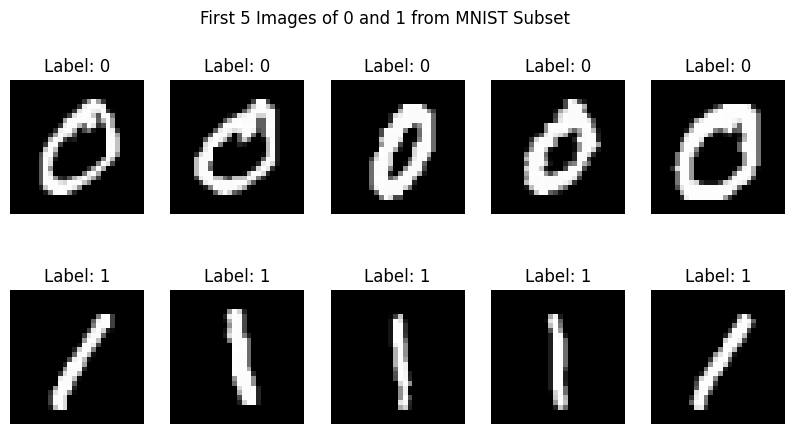

In [10]:
# Separate images for label 0 and label 1
images_0 = X[y == 0]  # Get all images with label 0
images_1 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

## Step - 2 - Initializing the Weights:

In [11]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

Question 3: What does the weights array represent?

The weights represent the importance or influence of each input feature (in this case, each of the 784 pixels).

A positive weight means that pixel suggests the image belongs to the target class.

A negative weight means that pixel suggests it does not.

A zero weight means that pixel is currently being ignored.

Question 4: Why initialize to zero? What is the effect?

We initialize to zero to give the model a neutral starting point with no prior "opinion" on which pixels are important.

The Effects:

- Symmetry: In a single Perceptron, starting at zero is fine because the first error will immediately nudge the weights in the right direction.

- Initial Output: The very first prediction will always be 0 (since $0 \times \text{pixel} + 0 = 0$), meaning the model will always fail the first positive example it sees to start the learning process.

- Simplicity: It is computationally easy, though for deeper neural networks, zero initialization can cause "stagnation" (which is why those models use random numbers instead).

## Step - 3 - Make a Decision function:

In [12]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    # Linear combination: z = w1*x1 + w2*x2 + ... + bias
    predictions = np.dot(X, weights) + bias

    # Activation function (step function):
    # If prediction > 0, return 1, else return 0
    y_pred_all = np.where(predictions > 0, 1, 0)

    return y_pred_all

## Step - 3 - Implement the Perceptron Learning Algorithm

In [13]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """
    n_samples = X.shape[0]

    for epoch in range(epochs):
        total_correct = 0

        for i in range(n_samples):
            # 1. Calculate the linear combination (z = w*x + b)
            linear_output = np.dot(X[i], weights) + bias

            # 2. Apply the Step Function (Activation)
            y_pred = 1 if linear_output > 0 else 0

            # 3. Calculate the error (Target - Prediction)
            error = y[i] - y_pred

            # 4. Update weights and bias if there is an error
            if error != 0:
                weights += learning_rate * error * X[i]
                bias += learning_rate * error
            else:
                total_correct += 1

        # Calculate accuracy for the current epoch
        accuracy = total_correct / n_samples

        # Optional: Stop early if 100% accuracy is reached
        if total_correct == n_samples:
            break

    return weights, bias, accuracy

Question - 5: What is the purpose of the output = np.dot(X[i], weights) + bias line?



This line calculates the weighted sum (linear combination) of the inputs. It multiplies every feature by its corresponding weight and adds the bias. This result determines how close the data point is to the decision boundary before the step function turns it into a 0 or 1.

Question 6: What happens when the prediction is wrong?

When the prediction is wrong, the Update Rule is triggered to fix the error:

Weights: Adjusted by adding learning_rate * error * X[i]. This shifts the weights to favor the correct class.

Bias: Adjusted by adding learning_rate * error. This shifts the "threshold" for the neuron to fire.

If the prediction is correct, the error is 0, and no changes are made.

Question 7: Why is final accuracy important and what do you expect?

Importance: It measures how well the model has "learned" to separate the classes. It tells you if the model is reliable for making future predictions.

Expectation: * If the data is linearly separable (can be split by a straight line), accuracy should eventually reach 1.0 (100%).

If the data is not linearly separable (like XOR), the accuracy will fluctuate and never reach 100%.

## Training the Perceptron

In [14]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  1.0


## Step 5: Visualize Misclassified Images

In [15]:
# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Question - 8:What does misclassified idx store, and how is it used in this code?

It stores the indices (position numbers) of all the data points where the model's prediction did not match the actual label.

- How it's used: The code uses these indices to pull the specific "failed" images from the dataset X so they can be plotted. It allows you to see exactly which images (like a messy "4" that looks like a "9") confused the Perceptron.

Question - 9: How do you interpret the result if the output is ”All images were correctly classified!”?

It means the model reached 100% accuracy on the dataset provided.

- Interpretation: This indicates the data is linearly separable, meaning the Perceptron found a perfect "line" (or hyperplane) that separates one class from the other without a single mistake.

#4.4 Task 3: Perceptron Algorithm for 3 vs 5 Classification.

**4.5 To - Do:**
1. Implement each Step as we implemented above.
2. Visualize the final misclassified images and Provide your conclusion.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/week-3 AI ML/Copy of mnist_3_and_5.csv")  # Add the correct file path if necessary

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values  # 784 pixels
y = df_0_1["label"].values  # Labels (0 or 1)

y = np.where(y == 3, 0, 1)   #  remap: 3 → 0, 5 → 1

# Check the shape of the features and labels
print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

print(y)



Feature matrix shape: (2741, 784)
Label vector shape: (2741,)
[1 0 0 ... 0 0 1]


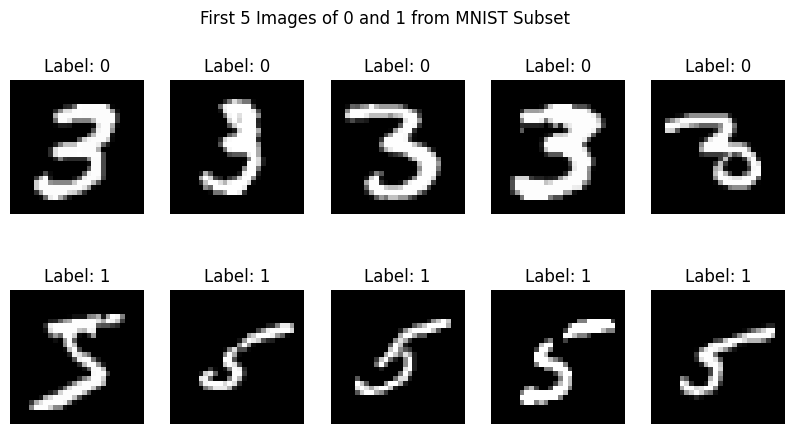

In [46]:
# Separate images for label 0 and label 1
images_3 = X[y == 0]  # Get all images with label 0
images_5 = X[y == 1]  # Get all images with label 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

# Check if the arrays have the required amount of data
if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        # Plot digit 0
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")
        # Plot digit 1
        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")
    plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
    plt.show()

In [25]:
# Initialize weights and bias
weights = np.zeros(X.shape[1])  # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [36]:
import numpy as np

def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - weights: Updated weights after training
    - bias: Updated bias after training

    Returns:
    - y_pred_all: The predicted labels for the input data
    """
    # Linear combination: z = w1*x1 + w2*x2 + ... + bias
    predictions = np.dot(X, weights) + bias

    # Activation function (step function):
    # If prediction > 0, return 1, else return 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all

In [47]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
    - X: Features (input data) as a numpy array of shape (n_samples, n_features)
    - y: Labels (true output) as a numpy array of shape (n_samples,)
    - weights: Initial weights as a numpy array of shape (n_features,)
    - bias: Initial bias value (scalar)
    - learning_rate: Learning rate for weight updates (default is 0.1)
    - epochs: Number of iterations to train the model (default is 100)

    Returns:
    - weights: Updated weights after training
    - bias: Updated bias after training
    - accuracy: Total correct prediction.
    """
    # Step 3: Perceptron Learning Algorithm
    for _ in range(epochs):
          for i in range(len(X)):
              # Linear output
              linear_output = np.dot(X[i], weights) + bias

              # Step activation
              y_pred = 1 if linear_output >= 0 else 0

              # Error
              error = y[i] - y_pred

              # Update weights and bias
              weights = weights + learning_rate * error * X[i]
              bias = bias + learning_rate * error

    # Final accuracy calculation
    predictions = np.where(np.dot(X, weights) + bias >= 0, 1, 0)
    accuracy = np.sum(predictions == y) /len(y)

    return weights, bias, accuracy

In [48]:
# After training the model with the perceptron_learning_algorithm
weights, bias, accuracy = train_perceptron(X, y, weights, bias)

# Evaluate the model using the new function
print("The Final Accuracy is: ", accuracy)

The Final Accuracy is:  0.45859175483400216


Final Accuracy: 0.4586


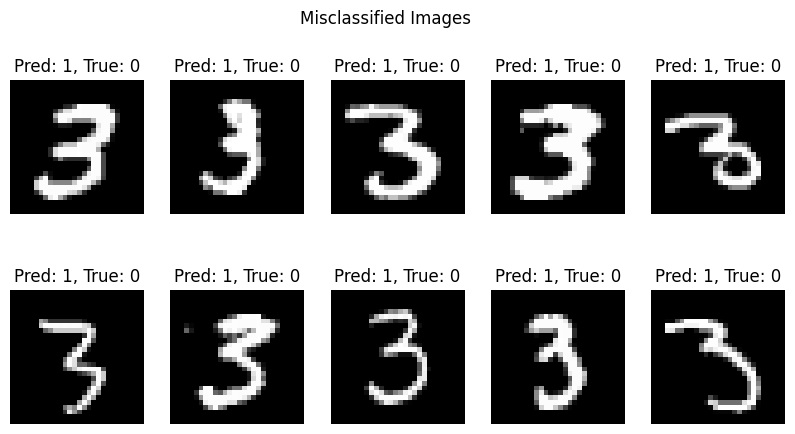

In [49]:

# Get predictions for all data points
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")
